In [ ]:
from google.colab import files

uploaded = files.upload()

Saving evaluation_window.csv to evaluation_window.csv
Saving moirai2_predictions.csv to moirai2_predictions.csv
Saving timesfm_predictions.csv to timesfm_predictions.csv


In [ ]:
import os

files_to_check = [
    "/content/evaluation_window.csv",
    "/content/timesfm_predictions.csv",
    "/content/moirai2_predictions.csv",
]

for path in files_to_check:
    assert os.path.exists(path), f"Missing: {path}"
    print(f"✅ {os.path.basename(path)}")

✅ evaluation_window.csv
✅ timesfm_predictions.csv
✅ moirai2_predictions.csv


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# 1. LOAD VERIFIED ARTIFACTS
# ============================================================

ev = pd.read_csv(
    "/content/evaluation_window.csv",
    parse_dates=["timestamp"]
)

tfm = pd.read_csv(
    "/content/timesfm_predictions.csv",
    parse_dates=["timestamp"]
)

moirai = pd.read_csv(
    "/content/moirai2_predictions.csv",
    parse_dates=["timestamp"]
)

# Ground-truth section from the original locked window
gt = (
    ev[ev["split"] == "ground_truth"]
    [["timestamp", "traffic_speed"]]
    .rename(columns={"traffic_speed": "ground_truth"})
    .reset_index(drop=True)
)

# ============================================================
# 2. STRICT INTEGRITY CHECKS
# ============================================================

assert len(gt) == 24
assert len(tfm) == 24
assert len(moirai) == 24

# Exact same timestamps
assert np.array_equal(
    gt["timestamp"].to_numpy(),
    tfm["timestamp"].to_numpy()
), "TimesFM timestamps do not match evaluation window."

assert np.array_equal(
    gt["timestamp"].to_numpy(),
    moirai["timestamp"].to_numpy()
), "Moirai timestamps do not match evaluation window."

# Exact same ground truth
assert np.allclose(
    gt["ground_truth"].to_numpy(dtype=float),
    tfm["ground_truth"].to_numpy(dtype=float)
), "TimesFM ground truth mismatch."

assert np.allclose(
    gt["ground_truth"].to_numpy(dtype=float),
    moirai["ground_truth"].to_numpy(dtype=float)
), "Moirai ground truth mismatch."

# ============================================================
# 3. BUILD FINAL COMPARISON DATASET
# ============================================================

comparison = pd.DataFrame({
    "timestamp": gt["timestamp"],
    "ground_truth": gt["ground_truth"].astype(float),
    "timesfm_2_5": tfm["timesfm_prediction"].astype(float),
    "moirai_2_0": moirai["moirai2_prediction"].astype(float),
})

assert comparison.notna().all().all()
assert len(comparison) == 24

# ============================================================
# 4. RECOMPUTE METRICS FROM SAVED ARTIFACTS
# ============================================================

y = comparison["ground_truth"].to_numpy()

timesfm_pred = comparison["timesfm_2_5"].to_numpy()
moirai_pred = comparison["moirai_2_0"].to_numpy()

timesfm_mae = np.mean(np.abs(y - timesfm_pred))
timesfm_rmse = np.sqrt(np.mean((y - timesfm_pred) ** 2))

moirai_mae = np.mean(np.abs(y - moirai_pred))
moirai_rmse = np.sqrt(np.mean((y - moirai_pred) ** 2))

# Check against previously verified results
assert np.isclose(timesfm_mae, 2.3031, atol=1e-4)
assert np.isclose(timesfm_rmse, 2.9794, atol=1e-4)

assert np.isclose(moirai_mae, 1.6552, atol=1e-4)
assert np.isclose(moirai_rmse, 2.7551, atol=1e-4)

# ============================================================
# 5. FINAL MODEL COMPARISON TABLE
# ============================================================

metrics = pd.DataFrame([
    {
        "model": "TimesFM",
        "version": "2.5",
        "checkpoint": "google/timesfm-2.5-200m-pytorch",
        "forecast_type": "q=0.5 median",
        "context_length": 96,
        "forecast_horizon": 24,
        "mae": timesfm_mae,
        "rmse": timesfm_rmse,
    },
    {
        "model": "Moirai",
        "version": "2.0",
        "checkpoint": "Salesforce/moirai-2.0-R-small",
        "forecast_type": "q=0.5 median",
        "context_length": 96,
        "forecast_horizon": 24,
        "mae": moirai_mae,
        "rmse": moirai_rmse,
    }
])

# ============================================================
# 6. SAVE FINAL ARTIFACTS
# ============================================================

comparison.to_csv(
    "/content/model_predictions_comparison.csv",
    index=False
)

metrics.to_csv(
    "/content/model_metrics_comparison.csv",
    index=False
)

# ============================================================
# 7. REPORT
# ============================================================

print("==========================================")
print("FINAL MODEL COMPARISON — INTEGRITY REPORT")
print("==========================================")
print()
print("Timestamps identical: YES")
print("Ground truth identical: YES")
print("Forecast points per model: 24")
print("Context length: 96")
print("Forecast horizon: 24")
print("Point forecast definition: q=0.5 median")
print("Training / fine-tuning: NONE")
print()

print(metrics[
    ["model", "version", "mae", "rmse"]
].to_string(index=False))

print()
print("Saved:")
print("/content/model_predictions_comparison.csv")
print("/content/model_metrics_comparison.csv")

print()
print("✅ FINAL COMPARISON DATASET VERIFIED")

FINAL MODEL COMPARISON — INTEGRITY REPORT

Timestamps identical: YES
Ground truth identical: YES
Forecast points per model: 24
Context length: 96
Forecast horizon: 24
Point forecast definition: q=0.5 median
Training / fine-tuning: NONE

  model version      mae     rmse
TimesFM     2.5 2.303082 2.979414
 Moirai     2.0 1.655187 2.755086

Saved:
/content/model_predictions_comparison.csv
/content/model_metrics_comparison.csv

✅ FINAL COMPARISON DATASET VERIFIED


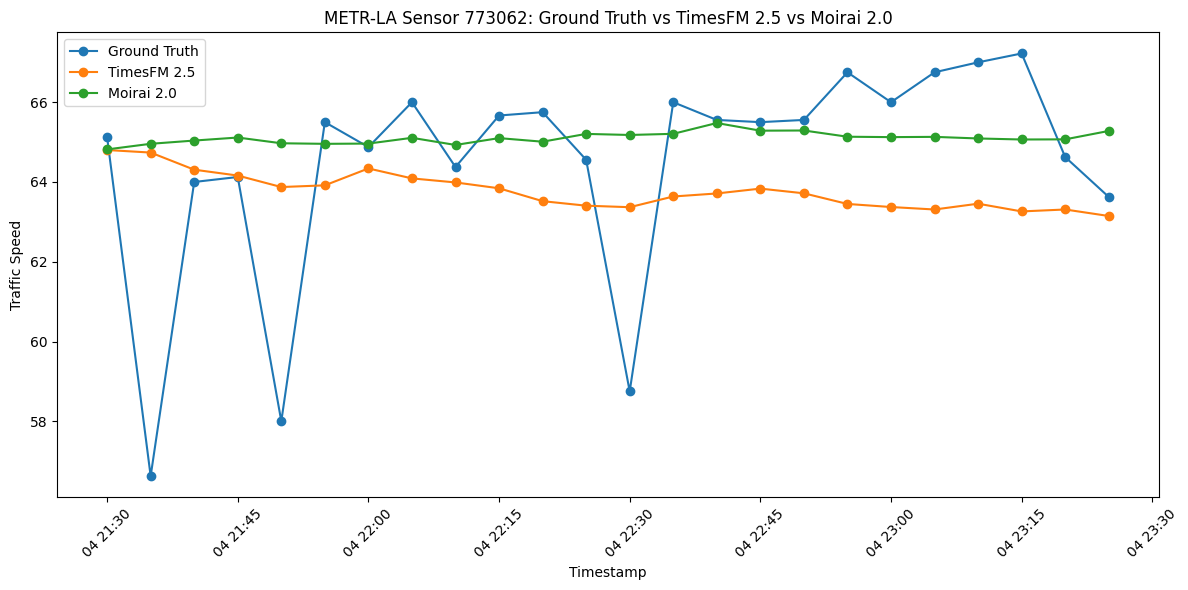

Saved: /content/final_model_comparison_plot.png

  model  version      mae     rmse
TimesFM      2.5 2.303082 2.979414
 Moirai      2.0 1.655187 2.755086


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

comparison = pd.read_csv(
    "/content/model_predictions_comparison.csv",
    parse_dates=["timestamp"]
)

metrics = pd.read_csv(
    "/content/model_metrics_comparison.csv"
)

# Grafik
plt.figure(figsize=(12, 6))
plt.plot(comparison["timestamp"], comparison["ground_truth"], marker="o", label="Ground Truth")
plt.plot(comparison["timestamp"], comparison["timesfm_2_5"], marker="o", label="TimesFM 2.5")
plt.plot(comparison["timestamp"], comparison["moirai_2_0"], marker="o", label="Moirai 2.0")

plt.title("METR-LA Sensor 773062: Ground Truth vs TimesFM 2.5 vs Moirai 2.0")
plt.xlabel("Timestamp")
plt.ylabel("Traffic Speed")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plot_path = "/content/final_model_comparison_plot.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)
print()
print(metrics[["model", "version", "mae", "rmse"]].to_string(index=False))

In [ ]:
from google.colab import files

files.download("/content/final_model_comparison_plot.png")
files.download("/content/model_predictions_comparison.csv")
files.download("/content/model_metrics_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>